In [259]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from tqdm import tqdm
from sklearn import preprocessing
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score
from sklearn.metrics import confusion_matrix

In [ ]:
df = pd.read_csv("C:/Users/nguye/DS102/Lab02/dataset.csv")

In [261]:
display(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4424 entries, 0 to 4423
Data columns (total 35 columns):
 #   Column                                          Non-Null Count  Dtype  
---  ------                                          --------------  -----  
 0   Marital status                                  4424 non-null   int64  
 1   Application mode                                4424 non-null   int64  
 2   Application order                               4424 non-null   int64  
 3   Course                                          4424 non-null   int64  
 4   Daytime/evening attendance                      4424 non-null   int64  
 5   Previous qualification                          4424 non-null   int64  
 6   Nacionality                                     4424 non-null   int64  
 7   Mother's qualification                          4424 non-null   int64  
 8   Father's qualification                          4424 non-null   int64  
 9   Mother's occupation                      

None

In [262]:
df.head(10)

,Marital status,Application mode,Application order,Course,Daytime/evening attendance,Previous qualification,Nacionality,Mother's qualification,Father's qualification,Mother's occupation,...,Curricular units 2nd sem (credited),Curricular units 2nd sem (enrolled),Curricular units 2nd sem (evaluations),Curricular units 2nd sem (approved),Curricular units 2nd sem (grade),Curricular units 2nd sem (without evaluations),Unemployment rate,Inflation rate,GDP,Target
0,1,8,5,2,1,1,1,13,10,6,...,0,0,0,0,0.000000,0,10.8,1.4,1.74,Dropout
1,1,6,1,11,1,1,1,1,3,4,...,0,6,6,6,13.666667,0,13.9,-0.3,0.79,Graduate
2,1,1,5,5,1,1,1,22,27,10,...,0,6,0,0,0.000000,0,10.8,1.4,1.74,Dropout
3,1,8,2,15,1,1,1,23,27,6,...,0,6,10,5,12.400000,0,9.4,-0.8,-3.12,Graduate
4,2,12,1,3,0,1,1,22,28,10,...,0,6,6,6,13.000000,0,13.9,-0.3,0.79,Graduate
5,2,12,1,17,0,12,1,22,27,10,...,0,5,17,5,11.500000,5,16.2,0.3,-0.92,Graduate
6,1,1,1,12,1,1,1,13,28,8,...,0,8,8,8,14.345000,0,15.5,2.8,-4.06,Graduate
7,1,9,4,11,1,1,1,22,27,10,...,0,5,5,0,0.000000,0,15.5,2.8,-4.06,Dropout
8,1,1,3,10,1,1,15,1,1,10,...,0,6,7,6,14.142857,0,16.2,0.3,-0.92,Graduate
9,1,1,1,10,1,1,1,1,14,5,...,0,6,14,2,13.500000,0,8.9,1.4,3.51,Dropout


In [263]:
for col in df.columns:
  print(col, df[col].unique())

Marital status [1 2 4 3 5 6]
Application mode [ 8  6  1 12  9 17 15 16 14  4 13  7  3  2  5 18 10 11]
Application order [5 1 2 4 3 6 9 0]
Course [ 2 11  5 15  3 17 12 10 14 16  6  8 13  9  4  1  7]
Daytime/evening attendance [1 0]
Previous qualification [ 1 12 16 14  8  3 15  2  4  9 17 11  6  7 13  5 10]
Nacionality [ 1 15  3 14 12 18  5 11  8 17  4  9 13 16 10 21  2 20 19  6  7]
Mother's qualification [13  1 22 23  3  4 27  2 19 10 25  7  5 24  9 26 18 11 20 21  6  8 17 28
 12 14 16 15 29]
Father's qualification [10  3 27 28  1 14  5  4 24  2 29  9  7 26 18 30 12 15 25 31 16 11 20 33
 13 32  8  6 21 17 34 23 19 22]
Mother's occupation [ 6  4 10  8  5  2 16  1  7  3 12  9 20 28 13 29 23 32 30 18 24 19 11 21
 15 27 31 14 22 17 26 25]
Father's occupation [10  4  8 11  6  9  5  2  3 22  7  1 12 39 19 13 29 46 43 34 44 30 41 24
 23 45 35 26 28 36 16 37 31 42 20 15 40 25 21 17 32 38 27 18 14 33]
Displaced [1 0]
Educational special needs [0 1]
Debtor [0 1]
Tuition fees up to date [1 0]
Gend

In [264]:
def Target_encoder(Target):
  if Target == 'Graduate':
    return 1
  else:
    return 0
df['Target'] = df['Target'].apply(Target_encoder)

In [265]:
def preprocessing(df):
  BienNhiPhan = {"Daytime/evening attendance",
                "Displaced",
                "Educational special needs",
                "Debtor",
                "Tuition fees up to date",
                "Gender",
                "Scholarship holder",
                "International",
                 "Target"}
  for col in df.columns:
    if col not in BienNhiPhan:
      df[col] = (df[col] - df[col].mean())/df[col].std()
  return df
df = preprocessing(df)


In [266]:
for col in df.columns:
  print(col, df[col].unique())

Marital status [-0.29479543  1.35605896  4.65776772  3.00691334  6.3086221   7.95947648]
Application mode [ 0.21004482 -0.16738747 -1.11096819  0.9649094   0.39876097  1.90849012
  1.53105783  1.71977397  1.34234169 -0.54481975  1.15362554  0.02132868
 -0.7335359  -0.92225204 -0.35610361  2.09720626  0.58747711  0.77619325]
Application order [ 2.49061435 -0.55400513  0.20714974  1.72945948  0.96830461  3.25176922
  5.53523383 -1.31516   ]
Course [-1.82353777  0.25412433 -1.13098373  1.17752971 -1.59268642  1.6392324
  0.48497568  0.02327299  0.94667837  1.40838105 -0.90013239 -0.4384297
  0.71582702 -0.20757836 -1.36183508 -2.05438911 -0.66928105]
Daytime/evening attendance [1 0]
Previous qualification [-0.38636043  2.3888195   3.39797584  2.89339767  1.37966316  0.11821774
  3.14568676 -0.13407135  0.37050682  1.63195225  3.65026493  2.13653042
  0.87508499  1.12737408  2.64110859  0.62279591  1.88424133]
Nacionality [-0.14556962  7.86153533  0.99830251  7.28959926  6.14572713  9.5773

In [267]:
import numpy as np
from tqdm import tqdm

class QuanLogisticRegression:
    def __init__(self, epoch: int, lr: float):
        self.epoch = epoch
        self.lr = lr
        self.losses = []
        self.metrics = []
        self.w = None
        self.b = None

    def sigmoid(self, x: np.ndarray) -> np.ndarray:
        return 1 / (1 + np.exp(-x))

    def loss_func(self, y: np.ndarray, y_hat: np.ndarray) -> float:
        eps = 1e-10  # Đảm bảo tránh log(0)
        y_hat = np.clip(y_hat, eps, 1 - eps)
        return -np.mean(y * np.log(y_hat) + (1 - y) * np.log(1 - y_hat))

    def accuracy(self, y: np.ndarray, y_hat: np.ndarray) -> float:
        return (y == y_hat).mean()

    def predict(self, X: np.ndarray) -> np.ndarray:
        y_hat = self.sigmoid(np.dot(X, self.w) + self.b)
        return (y_hat >= 0.5).astype(int)  # Sửa dấu phẩy thành chấm

    def GradientDescent(self, X: np.ndarray, y: np.ndarray) -> None:
        n_sample, n_feature = X.shape
        if self.w is None:
            self.w = np.zeros(n_feature)
            self.b = 0

        for epoch in tqdm(range(self.epoch), desc="Epochs"):
            # Tính giá trị dự đoán
            y_hat = self.sigmoid(np.dot(X, self.w) + self.b)

            # Tính gradient cho w và b
            dw = np.dot(X.T, (y_hat - y)) / n_sample
            db = np.sum(y_hat - y) / n_sample

            # Cập nhật trọng số và bias
            self.w -= self.lr * dw
            self.b -= self.lr * db

            # Tính loss và accuracy sau mỗi epoch
            loss = self.loss_func(y, y_hat)
            y_pred = (y_hat >= 0.5).astype(int)  # Chuyển đổi sang nhãn nhị phân
            acc = self.accuracy(y, y_pred)

            self.losses.append(loss)
            self.metrics.append(acc)

            print(f"Epoch: {epoch+1}, Loss: {loss:.4f}, Accuracy: {acc:.4f}")

    def fit(self, X: np.ndarray, y: np.ndarray) -> None:
        self.GradientDescent(X, y)

In [268]:
X = df.drop('Target', axis = 1)
y = df['Target']


In [269]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [270]:
model = QuanLogisticRegression(epoch=1000, lr=0.0001)

In [271]:

model.fit(X_train, y_train)

Epochs:   0%|          | 0/1000 [00:00<?, ?it/s]

Epoch: 1, Loss: 0.6931, Accuracy: 0.5061
Epoch: 2, Loss: 0.6931, Accuracy: 0.7739
Epoch: 3, Loss: 0.6931, Accuracy: 0.7739
Epoch: 4, Loss: 0.6931, Accuracy: 0.7739
Epoch: 5, Loss: 0.6930, Accuracy: 0.7739
Epoch: 6, Loss: 0.6930, Accuracy: 0.7739
Epoch: 7, Loss: 0.6930, Accuracy: 0.7739
Epoch: 8, Loss: 0.6929, Accuracy: 0.7739
Epoch: 9, Loss: 0.6929, Accuracy: 0.7739
Epoch: 10, Loss: 0.6929, Accuracy: 0.7739
Epoch: 11, Loss: 0.6928, Accuracy: 0.7739
Epoch: 12, Loss: 0.6928, Accuracy: 0.7739
Epoch: 13, Loss: 0.6928, Accuracy: 0.7739
Epoch: 14, Loss: 0.6928, Accuracy: 0.7739
Epoch: 15, Loss: 0.6927, Accuracy: 0.7739
Epoch: 16, Loss: 0.6927, Accuracy: 0.7739
Epoch: 17, Loss: 0.6927, Accuracy: 0.7739
Epoch: 18, Loss: 0.6926, Accuracy: 0.7739
Epoch: 19, Loss: 0.6926, Accuracy: 0.7739
Epoch: 20, Loss: 0.6926, Accuracy: 0.7739
Epoch: 21, Loss: 0.6926, Accuracy: 0.7739
Epoch: 22, Loss: 0.6925, Accuracy: 0.7739
Epoch: 23, Loss: 0.6925, Accuracy: 0.7739
Epoch: 24, Loss: 0.6925, Accuracy: 0.7739
E

Epochs:   5%|▍         | 46/1000 [00:00<00:02, 444.70it/s]

Epoch: 43, Loss: 0.6919, Accuracy: 0.7739
Epoch: 44, Loss: 0.6919, Accuracy: 0.7739
Epoch: 45, Loss: 0.6918, Accuracy: 0.7739
Epoch: 46, Loss: 0.6918, Accuracy: 0.7739
Epoch: 47, Loss: 0.6918, Accuracy: 0.7739
Epoch: 48, Loss: 0.6918, Accuracy: 0.7739
Epoch: 49, Loss: 0.6917, Accuracy: 0.7739
Epoch: 50, Loss: 0.6917, Accuracy: 0.7739
Epoch: 51, Loss: 0.6917, Accuracy: 0.7739
Epoch: 52, Loss: 0.6916, Accuracy: 0.7739
Epoch: 53, Loss: 0.6916, Accuracy: 0.7739
Epoch: 54, Loss: 0.6916, Accuracy: 0.7739
Epoch: 55, Loss: 0.6915, Accuracy: 0.7739
Epoch: 56, Loss: 0.6915, Accuracy: 0.7739
Epoch: 57, Loss: 0.6915, Accuracy: 0.7739
Epoch: 58, Loss: 0.6915, Accuracy: 0.7739
Epoch: 59, Loss: 0.6914, Accuracy: 0.7739
Epoch: 60, Loss: 0.6914, Accuracy: 0.7739
Epoch: 61, Loss: 0.6914, Accuracy: 0.7739
Epoch: 62, Loss: 0.6913, Accuracy: 0.7739
Epoch: 63, Loss: 0.6913, Accuracy: 0.7739
Epoch: 64, Loss: 0.6913, Accuracy: 0.7739
Epoch: 65, Loss: 0.6913, Accuracy: 0.7739
Epoch: 66, Loss: 0.6912, Accuracy:

Epochs:   9%|▉         | 91/1000 [00:00<00:02, 436.96it/s]

...

Epoch: 884, Loss: 0.6690, Accuracy: 0.7742
Epoch: 885, Loss: 0.6690, Accuracy: 0.7742
Epoch: 886, Loss: 0.6690, Accuracy: 0.7742
Epoch: 887, Loss: 0.6690, Accuracy: 0.7742
Epoch: 888, Loss: 0.6689, Accuracy: 0.7742
Epoch: 889, Loss: 0.6689, Accuracy: 0.7742
Epoch: 890, Loss: 0.6689, Accuracy: 0.7742
Epoch: 891, Loss: 0.6689, Accuracy: 0.7742
Epoch: 892, Loss: 0.6688, Accuracy: 0.7745
Epoch: 893, Loss: 0.6688, Accuracy: 0.7745
Epoch: 894, Loss: 0.6688, Accuracy: 0.7745
Epoch: 895, Loss: 0.6688, Accuracy: 0.7745
Epoch: 896, Loss: 0.6687, Accuracy: 0.7745
Epoch: 897, Loss: 0.6687, Accuracy: 0.7745
Epoch: 898, Loss: 0.6687, Accuracy: 0.7745
Epoch: 899, Loss: 0.6687, Accuracy: 0.7745
Epoch: 900, Loss: 0.6686, Accuracy: 0.7745
Epoch: 901, Loss: 0.6686, Accuracy: 0.7745
Epoch: 902, Loss: 0.6686, Accuracy: 0.7745
Epoch: 903, Loss: 0.6686, Accuracy: 0.7745
Epoch: 904, Loss: 0.6685, Accuracy: 0.7745
Epoch: 905, Loss: 0.6685, Accuracy: 0.7745
Epoch: 906, Loss: 0.6685, Accuracy: 0.7745
Epoch: 907,

Epochs:  96%|█████████▌| 955/1000 [00:02<00:00, 480.87it/s]

Epoch: 939, Loss: 0.6677, Accuracy: 0.7745
Epoch: 940, Loss: 0.6677, Accuracy: 0.7745
Epoch: 941, Loss: 0.6676, Accuracy: 0.7745
Epoch: 942, Loss: 0.6676, Accuracy: 0.7745
Epoch: 943, Loss: 0.6676, Accuracy: 0.7745
Epoch: 944, Loss: 0.6676, Accuracy: 0.7745
Epoch: 945, Loss: 0.6675, Accuracy: 0.7745
Epoch: 946, Loss: 0.6675, Accuracy: 0.7745
Epoch: 947, Loss: 0.6675, Accuracy: 0.7745
Epoch: 948, Loss: 0.6675, Accuracy: 0.7745
Epoch: 949, Loss: 0.6674, Accuracy: 0.7745
Epoch: 950, Loss: 0.6674, Accuracy: 0.7745
Epoch: 951, Loss: 0.6674, Accuracy: 0.7745
Epoch: 952, Loss: 0.6674, Accuracy: 0.7745
Epoch: 953, Loss: 0.6673, Accuracy: 0.7745
Epoch: 954, Loss: 0.6673, Accuracy: 0.7745
Epoch: 955, Loss: 0.6673, Accuracy: 0.7745
Epoch: 956, Loss: 0.6673, Accuracy: 0.7745
Epoch: 957, Loss: 0.6672, Accuracy: 0.7745
Epoch: 958, Loss: 0.6672, Accuracy: 0.7745
Epoch: 959, Loss: 0.6672, Accuracy: 0.7745
Epoch: 960, Loss: 0.6672, Accuracy: 0.7745
Epoch: 961, Loss: 0.6671, Accuracy: 0.7742
Epoch: 962,

Epochs: 100%|██████████| 1000/1000 [00:02<00:00, 462.97it/s]

Epoch: 983, Loss: 0.6666, Accuracy: 0.7742
Epoch: 984, Loss: 0.6666, Accuracy: 0.7742
Epoch: 985, Loss: 0.6665, Accuracy: 0.7742
Epoch: 986, Loss: 0.6665, Accuracy: 0.7742
Epoch: 987, Loss: 0.6665, Accuracy: 0.7742
Epoch: 988, Loss: 0.6665, Accuracy: 0.7742
Epoch: 989, Loss: 0.6665, Accuracy: 0.7742
Epoch: 990, Loss: 0.6664, Accuracy: 0.7742
Epoch: 991, Loss: 0.6664, Accuracy: 0.7742
Epoch: 992, Loss: 0.6664, Accuracy: 0.7742
Epoch: 993, Loss: 0.6664, Accuracy: 0.7739
Epoch: 994, Loss: 0.6663, Accuracy: 0.7739
Epoch: 995, Loss: 0.6663, Accuracy: 0.7739
Epoch: 996, Loss: 0.6663, Accuracy: 0.7739
Epoch: 997, Loss: 0.6663, Accuracy: 0.7739
Epoch: 998, Loss: 0.6662, Accuracy: 0.7739
Epoch: 999, Loss: 0.6662, Accuracy: 0.7739
Epoch: 1000, Loss: 0.6662, Accuracy: 0.7739


In [272]:
y_pred = model.predict(X_test)
print (model.accuracy(y_test, y_pred))

0.7740112994350282


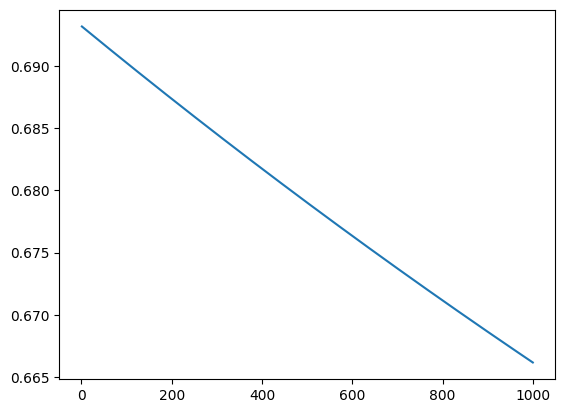

In [273]:
plt.plot(range(1, len(model.losses) + 1), model.losses)

In [274]:
class SoftmaxLogisticRegression:
    def __init__(self, epoch: int, lr: float, num_classes: int):
        self.epoch = epoch
        self.lr = lr
        self.num_classes = num_classes
        self.losses = []
        self.metrics = []
        self.w = None
        self.b = None

    def softmax(self, z: np.ndarray) -> np.ndarray:
        exp_z = np.exp(z - np.max(z, axis=1, keepdims=True))
        return exp_z / np.sum(exp_z, axis=1, keepdims=True)

    def loss_func(self, y: np.ndarray, y_hat: np.ndarray) -> float:
        eps = 1e-10
        y_hat = np.clip(y_hat, eps, 1 - eps)
        return -np.mean(np.sum(y * np.log(y_hat), axis=1))

    def accuracy(self, y: np.ndarray, y_hat: np.ndarray) -> float:
        return np.mean(np.argmax(y_hat, axis=1) == np.argmax(y, axis=1))

    def predict(self, X: np.ndarray) -> np.ndarray:
        z = np.dot(X, self.w) + self.b
        y_hat = self.softmax(z)
        return np.argmax(y_hat, axis=1)

    def GradientDescent(self, X: np.ndarray, y: np.ndarray) -> None:
        n_sample, n_feature = X.shape
        if self.w is None:
            self.w = np.zeros((n_feature, self.num_classes))
            self.b = np.zeros(self.num_classes)

        for epoch in tqdm(range(self.epoch), desc="Epochs"):
            # Tính giá trị dự đoán với softmax
            z = np.dot(X, self.w) + self.b
            y_hat = self.softmax(z)

            # Tính gradient cho W và b
            dw = np.dot(X.T, (y_hat - y)) / n_sample
            db = np.sum(y_hat - y, axis=0) / n_sample

            # Cập nhật trọng số và bias
            self.w -= self.lr * dw
            self.b -= self.lr * db

            # Tính loss và accuracy sau mỗi epoch
            loss = self.loss_func(y, y_hat)
            acc = self.accuracy(y, y_hat)

            self.losses.append(loss)
            self.metrics.append(acc)

            print(f"Epoch: {epoch+1}, Loss: {loss:.4f}, Accuracy: {acc:.4f}")

    def fit(self, X: np.ndarray, y: np.ndarray) -> None:
        self.GradientDescent(X, y)

In [275]:
df = pd.read_csv("/content/dataset.csv")

In [276]:
def Target_encoder(Target):
  if Target == 'Graduate':
    return 2
  elif Target == "Dropout":
    return 0
  else:
    return 1
df['Target'] = df['Target'].apply(Target_encoder)

In [277]:
X = df.drop('Target', axis = 1)
y = df['Target']

In [278]:
X.shape
y.value_counts()

,count
Target,
2,2209
0,1421
1,794


In [279]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state = 42)
y_train = np.eye(3)[y_train]
y_test = np.eye(3)[y_test]

In [280]:
model = SoftmaxLogisticRegression(epoch = 10000, lr = 0.001, num_classes = 3)
model.fit(X_train, y_train)


Epochs:   1%|          | 111/10000 [00:00<00:17, 552.77it/s]

Epoch: 1, Loss: 1.0986, Accuracy: 0.3122
Epoch: 2, Loss: 1.0174, Accuracy: 0.5061
Epoch: 3, Loss: 0.9986, Accuracy: 0.5061
Epoch: 4, Loss: 0.9876, Accuracy: 0.5061
Epoch: 5, Loss: 0.9783, Accuracy: 0.5061
Epoch: 6, Loss: 0.9698, Accuracy: 0.5066
Epoch: 7, Loss: 0.9618, Accuracy: 0.5326
Epoch: 8, Loss: 0.9544, Accuracy: 0.5702
Epoch: 9, Loss: 0.9473, Accuracy: 0.5928
Epoch: 10, Loss: 0.9406, Accuracy: 0.6067
Epoch: 11, Loss: 0.9343, Accuracy: 0.6157
Epoch: 12, Loss: 0.9283, Accuracy: 0.6208
Epoch: 13, Loss: 0.9226, Accuracy: 0.6270
Epoch: 14, Loss: 0.9172, Accuracy: 0.6307
Epoch: 15, Loss: 0.9121, Accuracy: 0.6324
Epoch: 16, Loss: 0.9072, Accuracy: 0.6335
Epoch: 17, Loss: 0.9025, Accuracy: 0.6349
Epoch: 18, Loss: 0.8980, Accuracy: 0.6378
Epoch: 19, Loss: 0.8938, Accuracy: 0.6392
Epoch: 20, Loss: 0.8897, Accuracy: 0.6403
Epoch: 21, Loss: 0.8858, Accuracy: 0.6414
Epoch: 22, Loss: 0.8821, Accuracy: 0.6437
Epoch: 23, Loss: 0.8785, Accuracy: 0.6457
Epoch: 24, Loss: 0.8751, Accuracy: 0.6474
E

Epochs:   2%|▏         | 167/10000 [00:00<00:18, 539.48it/s]

Epoch: 112, Loss: 0.7595, Accuracy: 0.6787
Epoch: 113, Loss: 0.7589, Accuracy: 0.6790
Epoch: 114, Loss: 0.7584, Accuracy: 0.6790
Epoch: 115, Loss: 0.7578, Accuracy: 0.6787
Epoch: 116, Loss: 0.7572, Accuracy: 0.6799
Epoch: 117, Loss: 0.7566, Accuracy: 0.6799
Epoch: 118, Loss: 0.7560, Accuracy: 0.6799
Epoch: 119, Loss: 0.7555, Accuracy: 0.6799
Epoch: 120, Loss: 0.7549, Accuracy: 0.6804
Epoch: 121, Loss: 0.7543, Accuracy: 0.6810
Epoch: 122, Loss: 0.7538, Accuracy: 0.6810
Epoch: 123, Loss: 0.7532, Accuracy: 0.6810
Epoch: 124, Loss: 0.7527, Accuracy: 0.6815
Epoch: 125, Loss: 0.7521, Accuracy: 0.6815
Epoch: 126, Loss: 0.7516, Accuracy: 0.6815
Epoch: 127, Loss: 0.7511, Accuracy: 0.6813
Epoch: 128, Loss: 0.7506, Accuracy: 0.6815
Epoch: 129, Loss: 0.7500, Accuracy: 0.6815
Epoch: 130, Loss: 0.7495, Accuracy: 0.6815
Epoch: 131, Loss: 0.7490, Accuracy: 0.6815
Epoch: 132, Loss: 0.7485, Accuracy: 0.6824
Epoch: 133, Loss: 0.7480, Accuracy: 0.6824
Epoch: 134, Loss: 0.7475, Accuracy: 0.6824
Epoch: 135,

Epochs:   3%|▎         | 276/10000 [00:00<00:17, 540.57it/s]

...

Epoch: 9778, Loss: 0.5778, Accuracy: 0.7593
Epoch: 9779, Loss: 0.5778, Accuracy: 0.7593
Epoch: 9780, Loss: 0.5778, Accuracy: 0.7593
Epoch: 9781, Loss: 0.5778, Accuracy: 0.7593
Epoch: 9782, Loss: 0.5777, Accuracy: 0.7593
Epoch: 9783, Loss: 0.5777, Accuracy: 0.7595
Epoch: 9784, Loss: 0.5777, Accuracy: 0.7595
Epoch: 9785, Loss: 0.5777, Accuracy: 0.7595
Epoch: 9786, Loss: 0.5777, Accuracy: 0.7595
Epoch: 9787, Loss: 0.5777, Accuracy: 0.7595
Epoch: 9788, Loss: 0.5777, Accuracy: 0.7595
Epoch: 9789, Loss: 0.5777, Accuracy: 0.7595
Epoch: 9790, Loss: 0.5777, Accuracy: 0.7595
Epoch: 9791, Loss: 0.5777, Accuracy: 0.7595
Epoch: 9792, Loss: 0.5777, Accuracy: 0.7595
Epoch: 9793, Loss: 0.5777, Accuracy: 0.7595
Epoch: 9794, Loss: 0.5777, Accuracy: 0.7595
Epoch: 9795, Loss: 0.5777, Accuracy: 0.7595
Epoch: 9796, Loss: 0.5777, Accuracy: 0.7595
Epoch: 9797, Loss: 0.5777, Accuracy: 0.7595
Epoch: 9798, Loss: 0.5777, Accuracy: 0.7595
Epoch: 9799, Loss: 0.5777, Accuracy: 0.7595
Epoch: 9800, Loss: 0.5777, Accur

Epochs: 100%|█████████▉| 9950/10000 [00:20<00:00, 502.01it/s]

Epoch: 9873, Loss: 0.5776, Accuracy: 0.7595
Epoch: 9874, Loss: 0.5776, Accuracy: 0.7595
Epoch: 9875, Loss: 0.5776, Accuracy: 0.7595
Epoch: 9876, Loss: 0.5776, Accuracy: 0.7595
Epoch: 9877, Loss: 0.5776, Accuracy: 0.7595
Epoch: 9878, Loss: 0.5776, Accuracy: 0.7595
Epoch: 9879, Loss: 0.5776, Accuracy: 0.7595
Epoch: 9880, Loss: 0.5776, Accuracy: 0.7595
Epoch: 9881, Loss: 0.5775, Accuracy: 0.7595
Epoch: 9882, Loss: 0.5775, Accuracy: 0.7595
Epoch: 9883, Loss: 0.5775, Accuracy: 0.7595
Epoch: 9884, Loss: 0.5775, Accuracy: 0.7595
Epoch: 9885, Loss: 0.5775, Accuracy: 0.7595
Epoch: 9886, Loss: 0.5775, Accuracy: 0.7595
Epoch: 9887, Loss: 0.5775, Accuracy: 0.7595
Epoch: 9888, Loss: 0.5775, Accuracy: 0.7595
Epoch: 9889, Loss: 0.5775, Accuracy: 0.7595
Epoch: 9890, Loss: 0.5775, Accuracy: 0.7595
Epoch: 9891, Loss: 0.5775, Accuracy: 0.7595
Epoch: 9892, Loss: 0.5775, Accuracy: 0.7595
Epoch: 9893, Loss: 0.5775, Accuracy: 0.7595
Epoch: 9894, Loss: 0.5775, Accuracy: 0.7595
Epoch: 9895, Loss: 0.5775, Accur

Epochs: 100%|██████████| 10000/10000 [00:21<00:00, 476.02it/s]

Epoch: 9977, Loss: 0.5774, Accuracy: 0.7601
Epoch: 9978, Loss: 0.5774, Accuracy: 0.7601
Epoch: 9979, Loss: 0.5774, Accuracy: 0.7601
Epoch: 9980, Loss: 0.5774, Accuracy: 0.7601
Epoch: 9981, Loss: 0.5774, Accuracy: 0.7601
Epoch: 9982, Loss: 0.5773, Accuracy: 0.7601
Epoch: 9983, Loss: 0.5773, Accuracy: 0.7601
Epoch: 9984, Loss: 0.5773, Accuracy: 0.7601
Epoch: 9985, Loss: 0.5773, Accuracy: 0.7601
Epoch: 9986, Loss: 0.5773, Accuracy: 0.7601
Epoch: 9987, Loss: 0.5773, Accuracy: 0.7601
Epoch: 9988, Loss: 0.5773, Accuracy: 0.7601
Epoch: 9989, Loss: 0.5773, Accuracy: 0.7601
Epoch: 9990, Loss: 0.5773, Accuracy: 0.7601
Epoch: 9991, Loss: 0.5773, Accuracy: 0.7601
Epoch: 9992, Loss: 0.5773, Accuracy: 0.7601
Epoch: 9993, Loss: 0.5773, Accuracy: 0.7601
Epoch: 9994, Loss: 0.5773, Accuracy: 0.7601
Epoch: 9995, Loss: 0.5773, Accuracy: 0.7601
Epoch: 9996, Loss: 0.5773, Accuracy: 0.7601
Epoch: 9997, Loss: 0.5773, Accuracy: 0.7601
Epoch: 9998, Loss: 0.5773, Accuracy: 0.7601
Epoch: 9999, Loss: 0.5773, Accur

In [281]:
y_pred = model.predict(X_test)
y_pred = np.eye(3)[y_pred]
print(model.accuracy(y_test, y_pred))

0.7310734463276836


In [282]:
df = pd.read_csv("/content/dataset.csv")

In [283]:
df['Target'] = df['Target'].apply(Target_encoder)
df = preprocessing(df)

In [284]:
X = df.drop('Target', axis = 1)
y = df['Target']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state = 42)

In [285]:
model = LogisticRegression(max_iter= 1000)
model.fit(X_train, y_train)

LogisticRegression(max_iter=1000)

In [286]:
y_pred = model.predict(X_test)
print(accuracy_score(y_test, y_pred))

0.7536723163841808
